In [106]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# KDE Features

In [119]:
X_train_kde = np.load('./X_train_kde.npy')
y_train_kde = np.load('./y_train.npy')
X_test_kde = np.load('./X_test_kde.npy')
y_test_kde = np.load('./y_test.npy')
scaler = StandardScaler()
scaler.fit(X_train_kde)
X_train_kde = scaler.transform(X_train_kde)
X_test_kde = scaler.transform(X_test_kde)

In [120]:
# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'solver': ['lbfgs', 'newton-cg', 'newton-cholesky'],
    'max_iter': randint(100, 5000),
}

search = RandomizedSearchCV(
    LogisticRegression(),
    param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
)

search.fit(X_train_kde, y_train_kde)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f2e20164cd0>,
                                        'solver': ['lbfgs', 'newton-cg',
                                                   'newton-cholesky']},
                   random_state=42)

In [121]:
best_logistic_reg = search.best_estimator_
best_logistic_reg.fit(X_train_kde, y_train_kde)
accuracy_score(y_test_kde, best_logistic_reg.predict(X_test_kde))

0.358

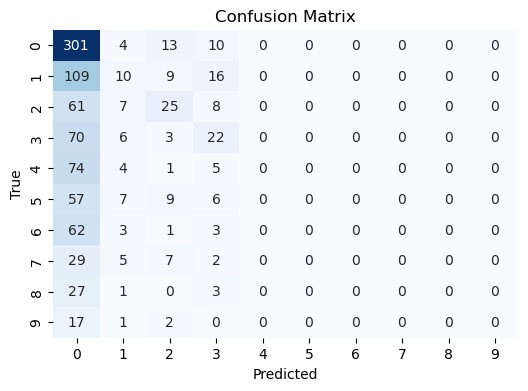

In [122]:
conf_matrix = confusion_matrix(y_test_kde, best_logistic_reg.predict(X_test_kde))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [123]:
per_class_accuracy = np.diag(conf_matrix) / conf_matrix.sum(axis=1)
per_class_accuracy

array([0.91768293, 0.06944444, 0.24752475, 0.21782178, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [124]:
X_train_kde_even = np.load('./X_train_kde_even.npy')
y_train_kde_even = np.load('./y_train_even.npy')
X_test_kde_even = np.load('./X_test_kde_even.npy')
y_test_kde_even = np.load('./y_test_even.npy')
scaler = StandardScaler()
scaler.fit(X_train_kde_even)
X_train_kde = scaler.transform(X_train_kde_even)
X_test_kde = scaler.transform(X_test_kde_even)

In [125]:
# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'solver': ['lbfgs', 'newton-cg', 'newton-cholesky'],
    'max_iter': randint(100, 5000),
}

search = RandomizedSearchCV(
    LogisticRegression(),
    param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
)

search.fit(X_train_kde_even, y_train_kde_even)

/home/nehooven/anaconda3/envs/ML_research/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/nehooven/anaconda3/envs/ML_research/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f2e1a0a5610>,
                                        'solver': ['lbfgs', 'newton-cg',
                                                   'newton-cholesky']},
                   random_state=42)

In [126]:
best_logistic_reg = search.best_estimator_
best_logistic_reg.fit(X_train_kde_even, y_train_kde_even)
accuracy_score(y_test_kde_even, best_logistic_reg.predict(X_test_kde_even))

/home/nehooven/anaconda3/envs/ML_research/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.166

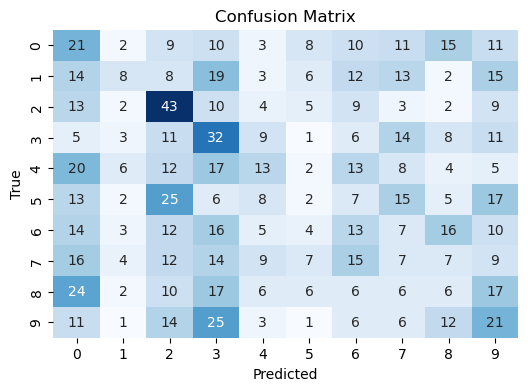

In [127]:
conf_matrix = confusion_matrix(y_test_kde_even, best_logistic_reg.predict(X_test_kde_even))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [128]:
per_class_accuracy = np.diag(conf_matrix) / conf_matrix.sum(axis=1)
per_class_accuracy

array([0.21, 0.08, 0.43, 0.32, 0.13, 0.02, 0.13, 0.07, 0.06, 0.21])

# K Means Features

In [73]:
X_train_kms = np.load('./X_train_kms.npy')
y_train_kms = np.load('./y_train.npy')
X_test_kms = np.load('./X_test_kms.npy')
y_test_kms = np.load('./y_test.npy')
scaler = StandardScaler()
scaler.fit(X_train_kms)
X_train_kms = scaler.transform(X_train_kms)
X_test_kms = scaler.transform(X_test_kms)

In [74]:
# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'solver': ['lbfgs', 'newton-cg', 'newton-cholesky'],
    'max_iter': randint(100, 5000),
}

search = RandomizedSearchCV(
    LogisticRegression(),
    param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
)

search.fit(X_train_kms, y_train_kms)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f2e19cf7f50>,
                                        'solver': ['lbfgs', 'newton-cg',
                                                   'newton-cholesky']},
                   random_state=42)

In [75]:
best_logistic_reg = search.best_estimator_
best_logistic_reg.fit(X_train_kms, y_train_kms)
accuracy_score(y_test_kms, best_logistic_reg.predict(X_test_kms))

0.362

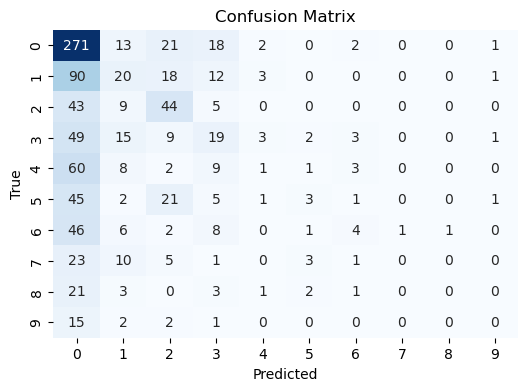

In [76]:
conf_matrix = confusion_matrix(y_test_kms, best_logistic_reg.predict(X_test_kms))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [77]:
per_class_accuracy = np.diag(conf_matrix) / conf_matrix.sum(axis=1)
per_class_accuracy

array([0.82621951, 0.13888889, 0.43564356, 0.18811881, 0.01190476,
       0.03797468, 0.05797101, 0.        , 0.        , 0.        ])

In [78]:
X_train_kms_even = np.load('./X_train_kms_even.npy')
y_train_kms_even = np.load('./y_train_even.npy')
X_test_kms_even = np.load('./X_test_kms_even.npy')
y_test_kms_even = np.load('./y_test_even.npy')
scaler = StandardScaler()
scaler.fit(X_train_kms_even)
X_train_kms_even = scaler.transform(X_train_kms_even)
X_test_kms_even = scaler.transform(X_test_kms_even)

In [79]:
# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'solver': ['lbfgs', 'newton-cg', 'newton-cholesky'],
    'max_iter': randint(100, 5000),
}

search = RandomizedSearchCV(
    LogisticRegression(),
    param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
)

search.fit(X_train_kms_even, y_train_kms_even)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f2e19d65f50>,
                                        'solver': ['lbfgs', 'newton-cg',
                                                   'newton-cholesky']},
                   random_state=42)

In [80]:
best_logistic_reg = search.best_estimator_
best_logistic_reg.fit(X_train_kms_even, y_train_kms_even)
accuracy_score(y_test_kms_even, best_logistic_reg.predict(X_test_kms_even))

0.195

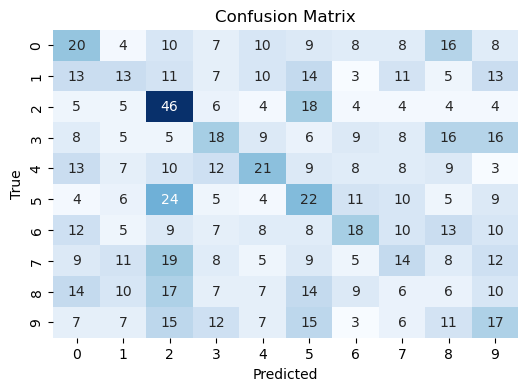

In [81]:
conf_matrix = confusion_matrix(y_test_kms_even, best_logistic_reg.predict(X_test_kms_even))

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [82]:
per_class_accuracy = np.diag(conf_matrix) / conf_matrix.sum(axis=1)

In [83]:
per_class_accuracy

array([0.2 , 0.13, 0.46, 0.18, 0.21, 0.22, 0.18, 0.14, 0.06, 0.17])